# 🧠 Finite State Controller Analysis

This notebook analyzes the **finite-state controller (FSC)** used for a **TurtleBot3 Gazebo simulation**.  
The objective is to **quantitatively and qualitatively** assess whether the finite-state controller behaves as expected.

---

## ⚙️ Controller Overview

Currently, the **finite-time controller** only generates **yaw-rate commands** (`angular.z`), while the **linear velocity** remains constant.  
The linear velocity is defined as a **hyperparameter** during initialization of the `HybrautNav` controller layer.

---

## 🔧 Controller Hyperparameters

| Parameter | Description | Value |
|------------|--------------|-------|
| `control_gain` | Proportional gain for yaw-rate control | `1.0` |
| `present_convergence` | Convergence factor for yaw-rate decay | `0.8` |
| `a` | Scaling constant for finite-time convergence | `1.0` |

---

## 🚀 Velocity Hyperparameters

| Parameter | Description | Value |
|------------|--------------|-------|
| `constant_velocity` | Constant forward linear velocity | `0.2 m/s` |

---

## 🔄 Yaw-Rate Hyperparameters

| Parameter | Description | Value |
|------------|--------------|-------|
| `control_gain` | Controller gain | `1.0` |
| `present_convergence` | Present-state convergence constant | `0.8` |
| `a` | Scaling factor for convergence rate | `1.0` |

---

## 🧾 Setup: Extract Data from ROS 2 Bag

This section reads and extracts `/cmd_vel` messages (Twist commands) from a recorded ROS 2 bag file.


In [1]:
import rosbag2_py
import matplotlib.pyplot as plt
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message
import matplotlib.pyplot as plt
import numpy as np

bag_path = '/home/mstolberger/ros2_ws/src/hybraut_nav/notebooks/bags/ros2_bag_finite_time_controller_2025_10_17-16_53_03'
topic_name = '/cmd_vel'

# Initialize reader
reader = rosbag2_py.SequentialReader()
storage_options = rosbag2_py.StorageOptions(uri=bag_path, storage_id='mcap')  # <-- FIXED
converter_options = rosbag2_py.ConverterOptions('', '')
reader.open(storage_options, converter_options)

# Get topic type
topics = reader.get_all_topics_and_types()
topic_type = next((t.type for t in topics if t.name == topic_name), None)
if topic_type is None:
    raise ValueError(f"Topic {topic_name} not found in bag!")

msg_type = get_message(topic_type)

timestamps, lin_x, lin_y, lin_z, ang_z = [], [], [], [], []

# Read messages
while reader.has_next():
    topic, data, t = reader.read_next()
    if topic == topic_name:
        msg = deserialize_message(data, msg_type)
        # TwistStamped includes .twist inside
        timestamps.append(t * 1e-9)  # ns → s
        lin_x.append(msg.twist.linear.x)
        lin_y.append(msg.twist.linear.y)
        lin_z.append(msg.twist.linear.z)
        ang_z.append(msg.twist.angular.z)
        


---

## 📈 Linear Velocity Analysis (`/cmd_vel`)

This section visualizes the **linear velocity commands** published by the finite-time controller on the `/cmd_vel` topic.  
Since the controller maintains a **constant forward velocity**, this plot helps verify that the velocity magnitude remains stable throughout the simulation.


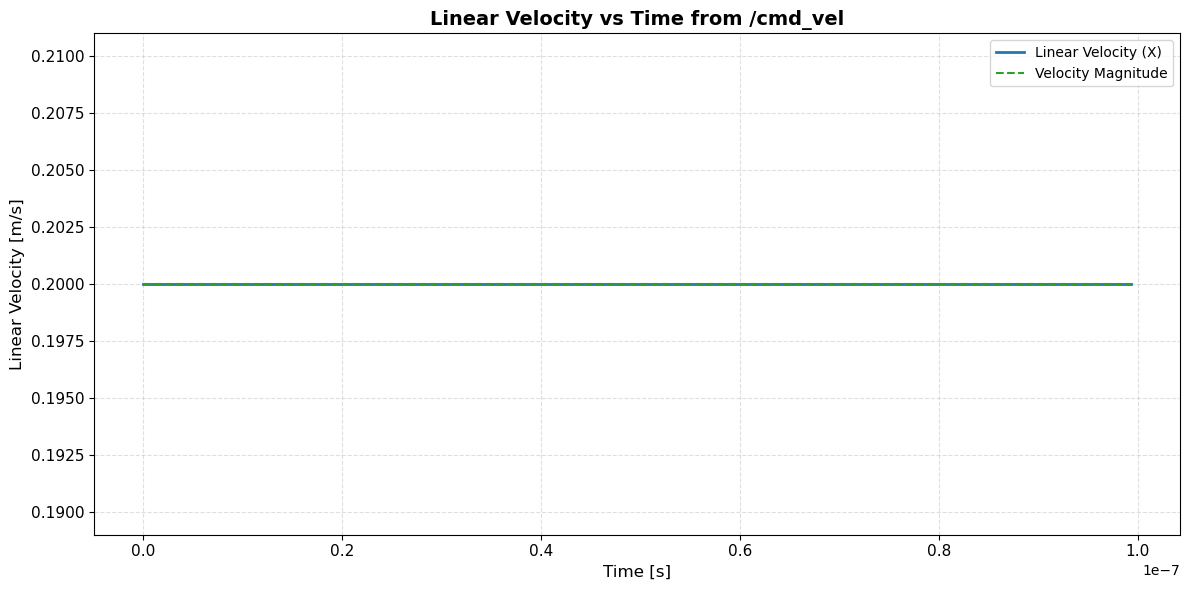

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Normalize timestamps (convert from ns → s) ---
timestamps = np.array(timestamps)
timestamps_sec = timestamps / 1e9
elapsed = timestamps_sec - timestamps_sec[0]

# --- Compute linear velocity magnitude ---
speed = np.sqrt(np.array(lin_x)**2 + np.array(lin_y)**2 + np.array(lin_z)**2)

# --- Plot linear velocity ---
plt.figure(figsize=(12, 6))
plt.plot(elapsed, lin_x, color='tab:blue', linewidth=2.0, label='Linear Velocity (X)')
plt.plot(elapsed, speed, '--', color='tab:green', linewidth=1.5, label='Velocity Magnitude')

plt.title('Linear Velocity vs Time from /cmd_vel', fontsize=14, weight='bold')
plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Linear Velocity [m/s]', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.4, linestyle='--')
plt.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()

---

## 🔄 Angular Velocity Analysis (`/cmd_vel`)

This section plots the **yaw-rate commands** (`angular.z`) generated by the `hybraut_controller` layer.  
The response curve reflects how the **finite-time controller** modulates angular velocity over time using the following **yaw-rate hyperparameters**:

| Parameter | Value |
|------------|--------|
| `control_gain` | `1.0` |
| `present_convergence` | `0.8` |
| `a` | `1.0` |

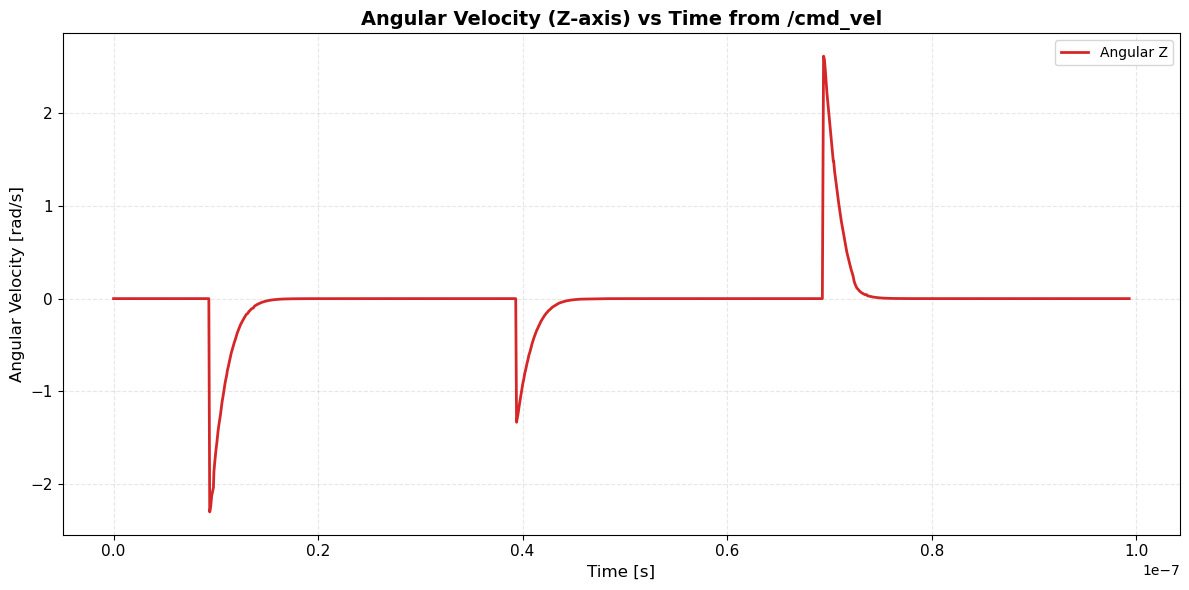

In [3]:
import matplotlib.pyplot as plt

# --- Angular velocity plot ---
plt.figure(figsize=(12, 6))
plt.plot(elapsed, ang_z, color='tab:red', linewidth=2.0, label='Angular Z')

plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Angular Velocity [rad/s]', fontsize=12)
plt.title('Angular Velocity (Z-axis) vs Time from /cmd_vel', fontsize=14, weight='bold')
plt.legend(loc='upper right')
plt.grid(alpha=0.3, linestyle='--')
plt.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()

---

## 🗺️ Path Trajectory from Odometry (`/odom`)

This section reconstructs the **TurtleBot3 trajectory** from the `/odom` topic.  
It visualizes how the **finite-time controller** drives the robot in the 2D plane (`x`, `y`) during the simulation.

In [4]:
import rosbag2_py
import matplotlib.pyplot as plt
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message
import matplotlib.pyplot as plt
import numpy as np
from nav_msgs.msg import Odometry

bag_path = '/home/mstolberger/ros2_ws/src/hybraut_nav/notebooks/bags/ros2_bag_finite_time_controller_2025_10_17-16_53_03'
topic_name = '/odom'

# Initialize reader
reader = rosbag2_py.SequentialReader()
storage_options = rosbag2_py.StorageOptions(uri=bag_path, storage_id='mcap')  # <-- FIXED
converter_options = rosbag2_py.ConverterOptions('', '')
reader.open(storage_options, converter_options)

# Get topic type
topics = reader.get_all_topics_and_types()
topic_type = next((t.type for t in topics if t.name == topic_name), None)
if topic_type is None:
    raise ValueError(f"Topic {topic_name} not found in bag!")

msg_type = get_message(topic_type)

timestamps, x, y, orientation = [], [], [], []

# Read messages
while reader.has_next():
    topic, data, t = reader.read_next()
    if topic == topic_name:
        msg: Odometry = deserialize_message(data, msg_type)
        # TwistStamped includes .twist inside
        timestamps.append(msg.header.stamp.sec * 1e9 + msg.header.stamp.nanosec)
        x.append(msg.pose.pose.position.x)
        y.append(msg.pose.pose.position.y)
        orientation.append(msg.pose.pose.orientation.z)

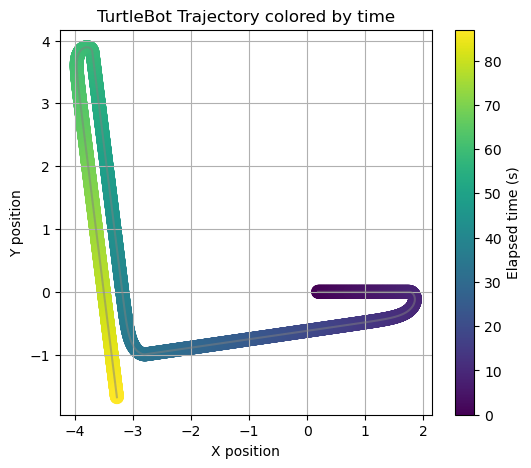

0.1853000095981931 3.267538393825881e-10
-3.276137942116393 -1.67894559958138


In [5]:
timestamps = np.array(timestamps)
# Convert nanoseconds → seconds and normalize
timestamps_sec = timestamps / 1e9
elapsed = timestamps_sec - timestamps_sec[0]

# Plot color-coded trajectory
plt.figure(figsize=(6,5))
sc = plt.scatter(x, y, c=elapsed, cmap='viridis', s=80)
plt.plot(x, y, color='gray', alpha=0.5)

cbar = plt.colorbar(sc)
cbar.set_label('Elapsed time (s)')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('TurtleBot Trajectory colored by time')
plt.grid(True)
plt.show()

print (x[0], y[0])
print (x[-1], y[-1])

## Video
This shows the video of the actual turtlebot3 being controller by the finite time controller

In [ ]:
from IPython.display import YouTubeVideo

# Extract the video ID from the URL
video_id = "W6FLMxwb96w"

# Display the video
YouTubeVideo(video_id, width=800, height=450)
